In [ ]:
import pandas as pd 
import duckdb
import os
import requests
from datetime import datetime
from dotenv import load_dotenv , find_dotenv
import math 

# 1. 환경 변수 로드
load_dotenv(find_dotenv())
MINIO_ENDPOINT = os.getenv('MINIO_ENDPOINT')
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY')

# 1. 환경 변수 로드
load_dotenv(find_dotenv())
OPINET_API_KEY_GROUP = ['OPINET_API_KEY_1', 'OPINET_API_KEY_2', 'OPINET_API_KEY_3', 
                        'OPINET_API_KEY_4', 'OPINET_API_KEY_5', 'OPINET_API_KEY_6' ] 
MINIO_ENDPOINT = os.getenv('MINIO_ENDPOINT') 
MINIO_ACCESS_KEY = os.getenv('MINIO_ACCESS_KEY')
MINIO_SECRET_KEY = os.getenv('MINIO_SECRET_KEY')


#2. duckdb를 통한 s3 읽기 설정
con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"SET s3_endpoint='{MINIO_ENDPOINT}';")
con.execute(f"SET s3_access_key_id='{MINIO_ACCESS_KEY}';")
con.execute(f"SET s3_secret_access_key='{MINIO_SECRET_KEY}';")
con.execute("SET s3_url_style='path'; SET s3_use_ssl='false';")


print("✅ DuckDB의 MinIO 접속 준비 완료!")



In [ ]:
# A1. 기초적인 Pearson Correlation 계산
df = con.sql(
    """
    with base as (
    select 
    part_dt
    , max(case when prodcd = 'B027' then price end ) as gasoline_prc
    , max(case when prodcd = 'D047' then price end ) as disel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where 1=1
    and part_dt >= '20260101'
    group by 1
    )
    select 
    CORR(gasoline_prc , disel_prc) as pearson_correlation
    from base 
"""
).df()

display(df)

In [ ]:
# A2. 연도별 Pearson Correlation 계산
import matplotlib

df = con.sql(
    """
    with base as (
    select 
    part_dt
    , max(case when prodcd = 'B027' then price end ) as gasoline_prc
    , max(case when prodcd = 'D047' then price end ) as disel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where 1=1
    group by 1
    )
    select 
    substring( cast(part_dt AS STRING), 1,4) as yyyy
    , CORR(gasoline_prc , disel_prc) as pearson_correlation
    from base 
    group by 1
    order by 1
"""
).df()



In [ ]:
# A1. 기초적인 Pearson Correlation 계산
df = con.sql(
    """
    select 
    part_dt
    , max(case when prodcd = 'B027' then price end ) as gasoline_prc
    , max(case when prodcd = 'D047' then price end ) as disel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where 1=1
    and part_dt >= '20200101'
    group by 1
    """
).df()

display(df)

In [ ]:
#A3. pandas로 corr 계산하기
import pandas as pd

corr = df['gasoline_prc'].corr(df['disel_prc'])
display(corr)

In [ ]:
#A4. 연도별 corr 계산하기
import pandas as pd 
df['yyyy'] = df['part_dt'].astype(str).str[:4]

yearly_corr = df.groupby('yyyy').apply(lambda y: y['disel_prc'].corr(y['gasoline_prc'])).reset_index().rename(columns = {0:'corr'})

display(yearly_corr)

In [ ]:
# A3. Pearson계산을 직접 수식으로 진행하면서 Cosine과 얼마나 유사한지 체크하자.
df = con.sql(
    """
    with step1 as (
    select 
    part_dt
    , 1 as join_key
    , max(case when prodcd = 'B027' then price end ) as gasoline_prc
    , max(case when prodcd = 'D047' then price end ) as diesel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where 1=1
    and part_dt >= '20260101'
    group by 1,2
    )
    , type_avg as (
    select
    1 as join_key
    , avg ( gasoline_prc) as avg_gasoline_prc
    , avg( diesel_prc) as avg_diesel_prc
    from step1 
    group by 1
    )
    , diff as (
    select
    t1.part_dt
    , t1.gasoline_prc
    , t2.avg_gasoline_prc
    , t1.gasoline_prc -  t2.avg_gasoline_prc as diff_gasoline
    , t1.diesel_prc
    , t2.avg_diesel_prc
    , t1.diesel_prc - t2.avg_diesel_prc as diff_diesel
    , (t1.gasoline_prc -  t2.avg_gasoline_prc) * (t1.diesel_prc - t2.avg_diesel_prc) as numerator
    from step1 t1
    left join type_avg t2
    on t1.join_key = t2.join_key
     )
    ,denom as (
    select
    1 as join_key
    , sqrt(sum(diff_gasoline ** 2)) as gasoline_l2_norm
    , sqrt(sum(diff_diesel ** 2)) as diesel_l2_norm
    , sqrt(sum(diff_gasoline ** 2)) * sqrt(sum(diff_diesel ** 2)) as denom
    from diff 
    group by 1
    )
    , numerator as (
    select
    1 as join_key 
    , sum(numerator) as numerator_sum
    from diff 
    group by 1
    )
    , manual_cal as (
    select
    t1.numerator_sum / t2.denom as pearson_r
    from numerator t1
    left join denom t2
    on t1.join_key = t2.join_key
    
    )
    , auto_cal as (
    select
    corr(gasoline_prc , diesel_prc) as auto_cal 
    
    from step1
    )
    select * from manual_cal union all
    select * from auto_cal 
    

    

    
    
"""
).df()

display(df)

In [15]:
# A3. Pearson계산을 직접 수식으로 진행하면서 Cosine과 얼마나 유사한지 체크하자.
df = con.sql(
  """  
    with step1 as (
   select 
    part_dt
    , max(case when prodcd = 'B027' then price end ) as gasoline_prc
    , max(case when prodcd = 'D047' then price end ) as diesel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where 1=1
    and part_dt >= '20260101'
    group by 1
    )
    , rnk as (
    select
    part_dt
    , gasoline_prc
    , diesel_prc
    , row_number() over (order by gasoline_prc desc ) as gasoline_rnk
    , row_number() over (order by diesel_prc desc ) as diesel_rnk
    from step1 
    )
    , avg_rnk as (
    select
    part_dt
    , gasoline_prc
    , diesel_prc
    , gasoline_rnk
    , diesel_rnk
    , avg( gasoline_rnk) over ( partition by gasoline_prc ) as gasoline_avg_rnk
    , avg( diesel_rnk) over ( partition by diesel_prc ) as diesel_avg_rnk
    from rnk
    )
    select
    corr( gasoline_avg_rnk , diesel_avg_rnk) as spearman
    , corr( gasoline_prc , diesel_prc) as pearson
    from avg_rnk

    """
).df()
display(df)


,spearman,pearson
0,0.991539,0.992898


In [18]:
# A3. Pearson계산을 직접 수식으로 진행하면서 Cosine과 얼마나 유사한지 체크하자.
df = con.sql(
  """  
    with step1 as (
   select 
   substring(cast(part_dt as varchar),1,4) as yyyy
    , part_dt
    , max(case when prodcd = 'B027' then price end ) as gasoline_prc
    , max(case when prodcd = 'D047' then price end ) as diesel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where 1=1
    -- and part_dt >= '20200101'
    group by 1,2
    )
    , rnk as (
    select
    yyyy
    , part_dt
    , gasoline_prc
    , diesel_prc
    , row_number() over (partition by yyyy order by gasoline_prc desc ) as gasoline_rnk
    , row_number() over (partition by yyyy order by diesel_prc desc ) as diesel_rnk
    from step1 
    
    )
    , avg_rnk as (
    select
    yyyy
    , part_dt
    , gasoline_prc
    , diesel_prc
    , gasoline_rnk
    , diesel_rnk
    , avg( gasoline_rnk) over ( partition by yyyy , gasoline_prc ) as gasoline_avg_rnk
    , avg( diesel_rnk) over ( partition by yyyy , diesel_prc ) as diesel_avg_rnk
    from rnk
    )
    select
    yyyy
    , corr( gasoline_avg_rnk , diesel_avg_rnk) as spearman
    , corr( gasoline_prc , diesel_prc) as pearson
    from avg_rnk
    group by 1
    order by 1

    """
).df()
display(df)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,yyyy,spearman,pearson
0,2008,0.994504,0.986442
1,2009,0.952887,0.871884
2,2010,0.964618,0.976378
3,2011,0.798271,0.943852
4,2012,0.954403,0.958399
5,2013,0.926578,0.954182
6,2014,0.997557,0.997692
7,2015,0.863682,0.838822
8,2016,0.991008,0.988086
9,2017,0.999088,0.999460


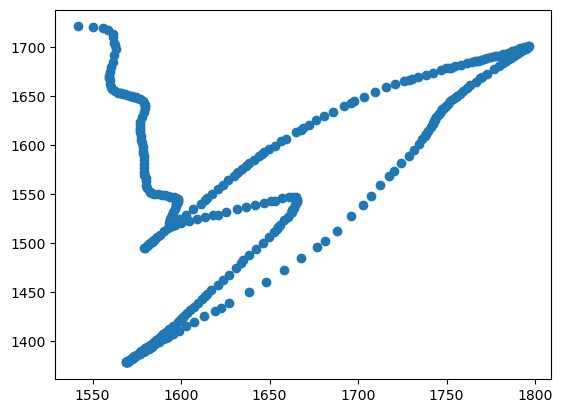

In [23]:
df = con.sql(
  """  
    
   select 
   substring(cast(part_dt as varchar),1,4) as yyyy
    , part_dt
    , max(case when prodcd = 'B027' then price end ) as gasoline_prc
    , max(case when prodcd = 'D047' then price end ) as diesel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where 1=1
    and part_dt >= '20230101'
    and part_dt <= '20231231'
    group by 1,2
    
""" 
).df()

import matplotlib.pyplot as plt
plt.scatter(df['gasoline_prc'] , df['diesel_prc'])
plt.show()

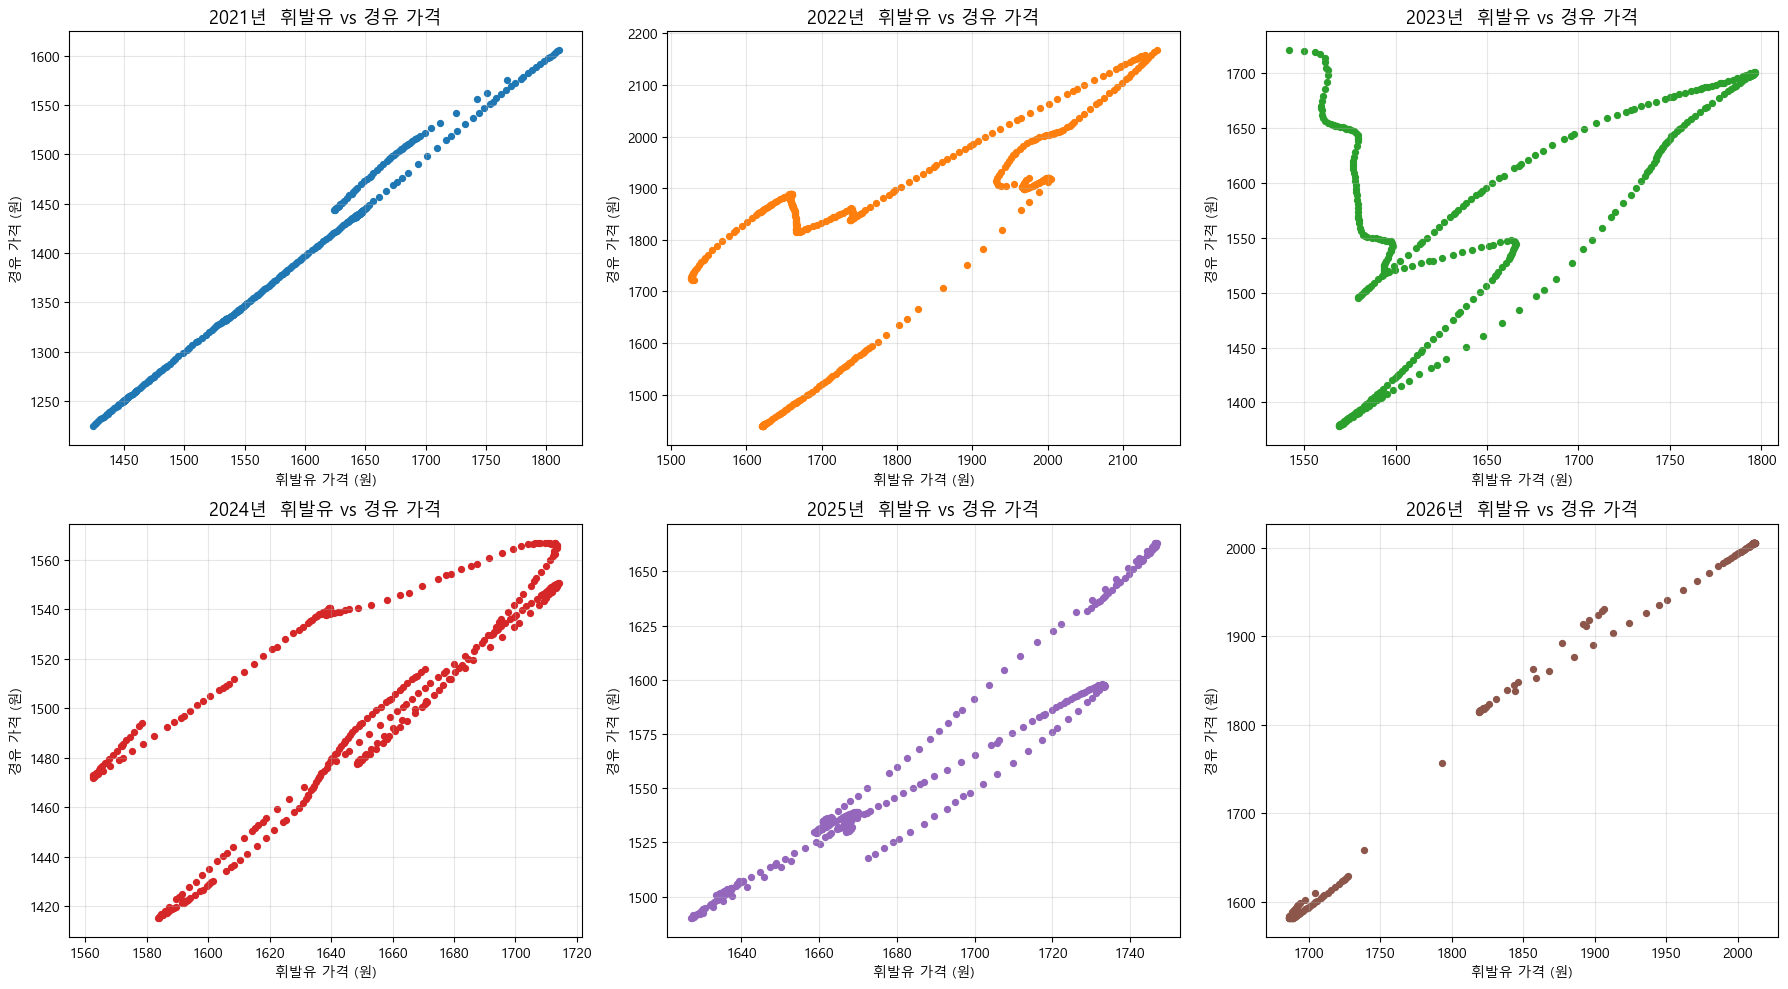

In [25]:
# A5. 2021~2026 연도별 산점도 (상관 좋은 해 vs 깨진 해 대조) — 블로그용
import matplotlib.pyplot as plt

# 한글 라벨 깨짐 방지 (Windows: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 기호 깨짐 방지

# 2021~2026 일별 휘발유/경유 가격 한 번에 뽑기
df = con.sql(
    """
    select
      substring(cast(part_dt as varchar), 1, 4) as yyyy
      , part_dt
      , max(case when prodcd = 'B027' then price end) as gasoline_prc
      , max(case when prodcd = 'D047' then price end) as diesel_prc
    from read_parquet('s3://petroleum-project/national_avg/price/*/*.parquet')
    where part_dt >= '20210101' and part_dt <= '20261231'
    group by 1, 2
    """
).df()

# 그릴 연도와 연도별 색
years  = ['2021', '2022', '2023', '2024', '2025', '2026']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown']

# 2행 3열 배치
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()   # 2차원 격자를 1줄로 펴서 순서대로 채우기 편하게

for ax, year, color in zip(axes, years, colors):
    sub = df[df['yyyy'] == year]
    ax.scatter(sub['gasoline_prc'], sub['diesel_prc'], color=color, s=18)
    ax.set_title(f'{year}년  휘발유 vs 경유 가격', fontsize=13)
    ax.set_xlabel('휘발유 가격 (원)')
    ax.set_ylabel('경유 가격 (원)')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


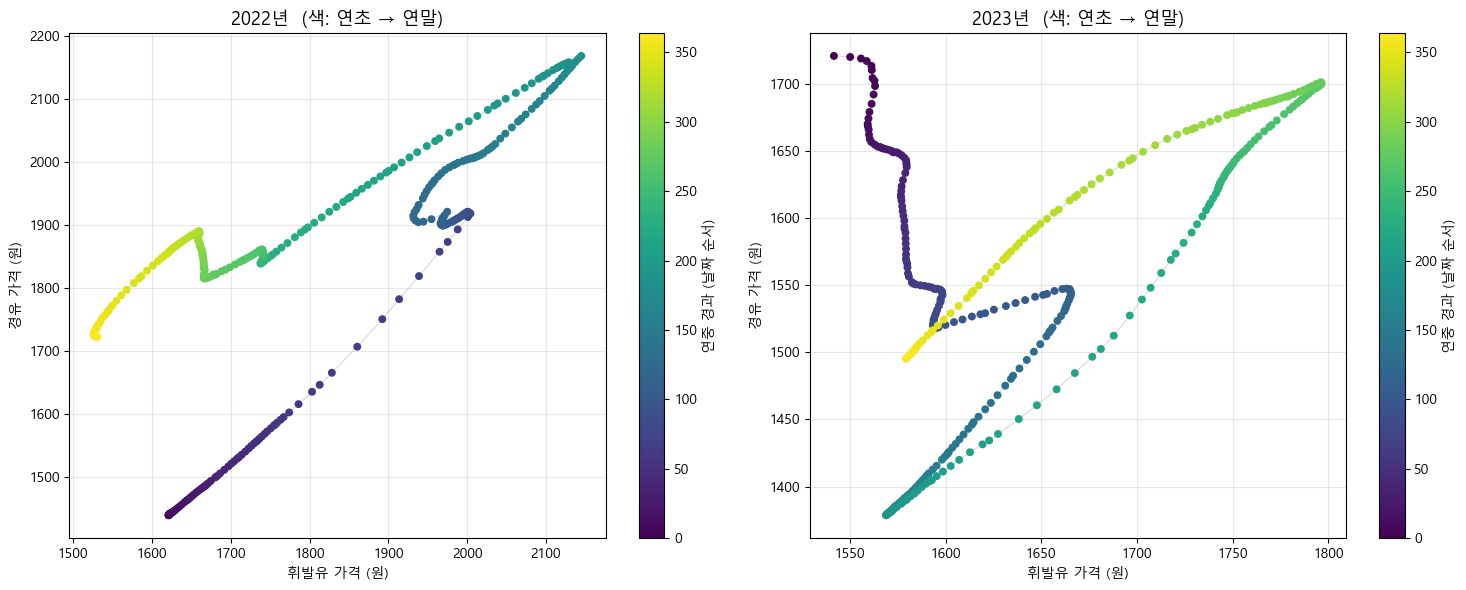

In [26]:
# A6. 산점도에 '시간 흐름'을 색으로 입히기 — 히스테리시스 가설 검증
#     (바로 위 A5 셀을 먼저 실행해서 df가 메모리에 있어야 함)
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, year in zip(axes, ['2022', '2023']):
    sub = df[df['yyyy'] == year].sort_values('part_dt')   # ① 날짜순으로 정렬

    # ② 시간순으로 옅은 회색 선 잇기 = 실제로 지나온 '경로'
    ax.plot(sub['gasoline_prc'], sub['diesel_prc'],
            color='gray', alpha=0.3, linewidth=0.8, zorder=1)

    # ③ 점 색 = 시간 순번 (연초=보라 → 연말=노랑)
    sc = ax.scatter(sub['gasoline_prc'], sub['diesel_prc'],
                    c=range(len(sub)), cmap='viridis', s=22, zorder=2)

    ax.set_title(f'{year}년  (색: 연초 → 연말)', fontsize=13)
    ax.set_xlabel('휘발유 가격 (원)')
    ax.set_ylabel('경유 가격 (원)')
    ax.grid(True, alpha=0.3)
    fig.colorbar(sc, ax=ax, label='연중 경과 (날짜 순서)')

plt.tight_layout()
plt.show()

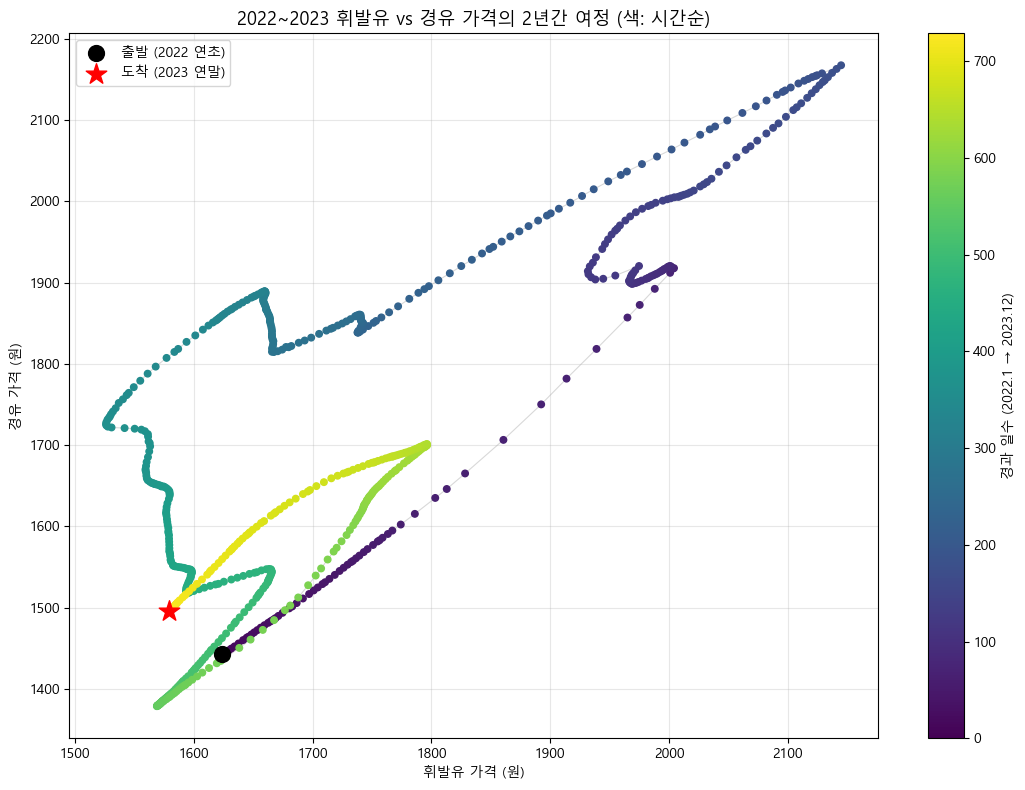

In [27]:
# A7. 2022~2023 두 해를 하나의 시간축으로 — '2년간의 가격 여정'
#     (A5 셀을 먼저 실행해서 df가 메모리에 있어야 함)
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 2022~2023만 뽑아 날짜순으로 한 줄로 정렬
sub = df[df['yyyy'].isin(['2022', '2023'])].sort_values('part_dt').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 8))

# 시간순 경로 (옅은 회색 선)
ax.plot(sub['gasoline_prc'], sub['diesel_prc'],
        color='gray', alpha=0.3, linewidth=0.8, zorder=1)

# 점 색 = 시간 순번 (2022.1 보라 → 2023.12 노랑)
sc = ax.scatter(sub['gasoline_prc'], sub['diesel_prc'],
                c=range(len(sub)), cmap='viridis', s=22, zorder=2)

# 시작점(2022 연초)과 끝점(2023 연말) 강조
ax.scatter(sub['gasoline_prc'].iloc[0], sub['diesel_prc'].iloc[0],
           color='black', marker='o', s=130, zorder=3, label='출발 (2022 연초)')
ax.scatter(sub['gasoline_prc'].iloc[-1], sub['diesel_prc'].iloc[-1],
           color='red', marker='*', s=240, zorder=3, label='도착 (2023 연말)')

ax.set_title('2022~2023 휘발유 vs 경유 가격의 2년간 여정 (색: 시간순)', fontsize=13)
ax.set_xlabel('휘발유 가격 (원)')
ax.set_ylabel('경유 가격 (원)')
ax.grid(True, alpha=0.3)
ax.legend()
fig.colorbar(sc, ax=ax, label='경과 일수 (2022.1 → 2023.12)')

plt.tight_layout()
plt.show()